In [1]:
#CIFAR10 10 sınıflı görüntü işleme sınıflandırma çalışması için kullanılan bir veri kümesidir. Bu veri kümesi, 60.000 renkli görüntüden oluşur ve her biri 32x32 piksel boyutundadır. Görüntüler, 10 farklı sınıfa ayrılmıştır: uçak, otomobil, kuş, kedi, geyik, köpek, kurbağa, at, gemi ve kamyon. Veri kümesi, eğitim ve test setleri olarak ikiye ayrılmıştır; eğitim seti 50.000 görüntü içerirken test seti 10.000 görüntü içerir.

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

c:\Users\alica\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train_data = datasets.CIFAR10(root="data", train=True, download=True, transform=ToTensor())
test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=ToTensor())

100%|██████████| 170498071/170498071 [00:16<00:00, 10410587.59it/s]


Extracting data\cifar-10-python.tar.gz to data
Files already downloaded and verified


In [4]:
type(train_data), type(test_data)

(torchvision.datasets.cifar.CIFAR10, torchvision.datasets.cifar.CIFAR10)

In [5]:
train_data[0]

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

In [6]:
image, label = train_data[0]

In [7]:
image

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [8]:
label

6

In [9]:
image.shape

torch.Size([3, 32, 32])

In [10]:
len(train_data), len(test_data)

(50000, 10000)

In [11]:
class_names = train_data.classes

In [12]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [13]:
len(class_names)

10

In [14]:
image = image.permute(1, 2, 0)
image.shape

torch.Size([32, 32, 3])

Text(0.5, 1.0, 'truck')

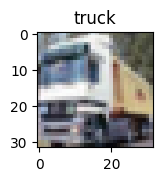

In [19]:
image, label = train_data[1]
image = image.permute(1, 2, 0)
plt.figure(figsize=(1.5, 1.5))
plt.imshow(image)
plt.title(class_names[label])

In [20]:
from torchvision import transforms